<a href="https://colab.research.google.com/github/DayraGL/TelecomX-Churn-Analysis/blob/main/analisis_churn_telecom_x.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# 0. Configuración e Instalación: (Importar pandas, matplotlib, seaborn y requests)**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests as req

#from bs4 import BeautifulSoup as bs

# **# 1. Extracción (E de ETL): Aquí irá el código de la API.**

In [3]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
data_json = req.get(url).json()
try:
  df = pd.DataFrame(data_json)

  print("✅ ¡Datos cargados exitosamente!")
  print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
  display(df.head())
except Exception as e:
  print(f"Error al cargar los datos: {e}")

✅ ¡Datos cargados exitosamente!
El dataset tiene 7267 filas y 6 columnas.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df = pd.json_normalize(data_json)
df.columns = [col.replace('.', '_') for col in df.columns]
print("✅ Datos normalizados.")
print(f"Nuevas columnas detectadas: {df.columns.tolist()[:10]}...") # Muestra las primeras 10
df

✅ Datos normalizados.
Nuevas columnas detectadas: ['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService']...


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [5]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [7]:
df.describe()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [8]:
print(df['account_Contract'].unique())

['One year' 'Month-to-month' 'Two year']


# **2. Transformación (T de ETL): Aquí limpié nulos y duplicados.**

In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [10]:
dups = df.duplicated().sum()

In [11]:
print("\n3. Revisión de categorías:")
columnas_categ = ['Churn', 'customer_gender', 'account_Contract', 'internet_InternetService']
for col in columnas_categ:
    print(f"   - {col}: {df[col].unique()}")


3. Revisión de categorías:
   - Churn: ['No' 'Yes' '']
   - customer_gender: ['Female' 'Male']
   - account_Contract: ['One year' 'Month-to-month' 'Two year']
   - internet_InternetService: ['DSL' 'Fiber optic' 'No']


In [12]:
df['account_Charges_Total'].isnull().sum()

np.int64(0)

In [13]:
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [14]:
incoherencia_tenure = df[(df['customer_tenure'] == 0) & (df['account_Charges_Total'] > 0)]
print(f"\n4. Clientes con tenure 0 y cargos > 0: {len(incoherencia_tenure)}")


4. Clientes con tenure 0 y cargos > 0: 0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [16]:
print("Filas que antes tenían espacios en blanco (nulos ocultos):")
print(df[df['account_Charges_Total'].isna()][['customerID', 'customer_tenure']])

Filas que antes tenían espacios en blanco (nulos ocultos):
      customerID  customer_tenure
975   1371-DWPAZ                0
1775  2520-SGTTA                0
1955  2775-SEFEE                0
2075  2923-ARZLG                0
2232  3115-CZMZD                0
2308  3213-VVOLG                0
2930  4075-WKNIU                0
3134  4367-NUYAO                0
3203  4472-LVYGI                0
4169  5709-LVOEQ                0
5599  7644-OMVMY                0


In [17]:
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(0)

# Vuelvo a vericar aquí
print(f"Nulos restantes en account_Charges_Total: {df['account_Charges_Total'].isnull().sum()}")

Nulos restantes en account_Charges_Total: 0


In [18]:
print("Filas que antes tenían espacios en blanco (nulos ocultos):")
print(df[df['account_Charges_Total'].isna()][['customerID', 'customer_tenure']])

Filas que antes tenían espacios en blanco (nulos ocultos):
Empty DataFrame
Columns: [customerID, customer_tenure]
Index: []


In [19]:
df['internet_OnlineBackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [20]:

# ESTANDARIZACIÓN Y TRADUCCIÓN

# Diccionario para renombrar columnas
nuevos_nombres = {
    'Churn': 'evasion',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_Partner': 'En_Pareja',
    'customer_Dependents': 'Dependientes',
    'customer_tenure': 'Meses_Permanencia',
    'phone_PhoneService': 'Servicio_Telefonico',
    'internet_InternetService': 'Tipo_Internet',
    'account_Contract': 'Tipo_Contrato',
    'account_PaymentMethod': 'Metodo_Pago',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'account_Charges_Total': 'Cargo_Total'
}

df = df.rename(columns=nuevos_nombres)

# ransformación Binaria/Encoding
# Convertimos 'Yes'/'No' a 1/0 para facilitar cálculos futuros
# Nota: Como ya había limpiado categorías, aplico a las columnas de interés
columnas_si_no = ['evasion', 'En_Pareja', 'Dependientes', 'Servicio_Telefonico', 'phone_MultipleLines', 'internet_OnlineBackup', 'internet_OnlineSecurity','internet_DeviceProtection','internet_TechSupport','internet_StreamingTV','internet_StreamingMovies','account_PaperlessBilling']

for col in columnas_si_no:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'Si': 1, 'Sí': 1})

#verifico cómo quedó la tabla
print("Estandarización")
print(f"Nuevas columnas: {df.columns.tolist()[:10]}...")
df[['evasion', 'En_Pareja', 'Dependientes', 'Servicio_Telefonico', 'phone_MultipleLines', 'internet_OnlineBackup', 'internet_OnlineSecurity','internet_DeviceProtection','internet_TechSupport','internet_StreamingTV','internet_StreamingMovies','account_PaperlessBilling']].head()

Estandarización
Nuevas columnas: ['customerID', 'evasion', 'Genero', 'Adulto_Mayor', 'En_Pareja', 'Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico', 'phone_MultipleLines', 'Tipo_Internet']...


,evasion,En_Pareja,Dependientes,Servicio_Telefonico,phone_MultipleLines,internet_OnlineBackup,internet_OnlineSecurity,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
0,0.0,1,1,1,0.0,1,0,0,1,1,0,1
1,0.0,0,0,1,1.0,0,0,0,0,0,1,0
2,1.0,0,0,1,0.0,0,0,1,0,0,0,1
3,1.0,1,0,1,0.0,1,0,1,0,1,1,1
4,1.0,1,0,1,0.0,0,0,0,1,1,0,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   evasion                    7043 non-null   float64
 2   Genero                     7267 non-null   object 
 3   Adulto_Mayor               7267 non-null   int64  
 4   En_Pareja                  7267 non-null   int64  
 5   Dependientes               7267 non-null   int64  
 6   Meses_Permanencia          7267 non-null   int64  
 7   Servicio_Telefonico        7267 non-null   int64  
 8   phone_MultipleLines        6560 non-null   float64
 9   Tipo_Internet              7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   int64  
 11  internet_OnlineBackup      7267 non-null   int64  
 12  internet_DeviceProtection  7267 non-null   int64  
 13  internet_TechSupport       7267 non-null   int64

In [22]:
df['evasion'].unique()

array([ 0.,  1., nan])

In [23]:
df['evasion'] = df['evasion'].fillna(0)

In [24]:
print("Valores Nulos")
print(df.isna().sum())

Valores Nulos
customerID                     0
evasion                        0
Genero                         0
Adulto_Mayor                   0
En_Pareja                      0
Dependientes                   0
Meses_Permanencia              0
Servicio_Telefonico            0
phone_MultipleLines          707
Tipo_Internet                  0
internet_OnlineSecurity        0
internet_OnlineBackup          0
internet_DeviceProtection      0
internet_TechSupport           0
internet_StreamingTV           0
internet_StreamingMovies       0
Tipo_Contrato                  0
account_PaperlessBilling       0
Metodo_Pago                    0
Cargo_Mensual                  0
Cargo_Total                    0
dtype: int64


In [25]:
df['internet_StreamingTV'].unique()

array([1, 0])

In [26]:
# Aseguro tipos de datos numéricos finales
df['evasion'] = df['evasion'].astype(int)

df['Cargo_Mensual'] = df['Cargo_Mensual'].astype(float)

print("Tipos de datos")

Tipos de datos


In [27]:
df

,customerID,evasion,Genero,Adulto_Mayor,En_Pareja,Dependientes,Meses_Permanencia,Servicio_Telefonico,phone_MultipleLines,Tipo_Internet,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0.0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.60,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1.0,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0.0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0.0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0.0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0.0,DSL,...,0,0,1,0,0,One year,0,Mailed check,55.15,742.90
7263,9992-RRAMN,1,Male,0,1,0,22,1,1.0,Fiber optic,...,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70
7264,9992-UJOEL,0,Male,0,0,0,2,1,0.0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7265,9993-LHIEB,0,Male,0,1,1,67,1,0.0,DSL,...,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


In [28]:
df[['phone_MultipleLines', 'internet_OnlineSecurity', 'phone_MultipleLines','internet_OnlineSecurity','internet_DeviceProtection','internet_TechSupport','internet_StreamingTV','internet_StreamingMovies']].isna().sum()

,0
phone_MultipleLines,707
internet_OnlineSecurity,0
phone_MultipleLines,707
internet_OnlineSecurity,0
internet_DeviceProtection,0
internet_TechSupport,0
internet_StreamingTV,0
internet_StreamingMovies,0


In [29]:
columnas_fillna = ['phone_MultipleLines', 'internet_OnlineSecurity',
            'internet_DeviceProtection', 'internet_TechSupport',
            'internet_StreamingTV', 'internet_StreamingMovies']
df[columnas_fillna] = df[columnas_fillna].fillna(0)

In [30]:
df.isna().sum()

,0
customerID,0
evasion,0
Genero,0
Adulto_Mayor,0
En_Pareja,0
Dependientes,0
Meses_Permanencia,0
Servicio_Telefonico,0
phone_MultipleLines,0
Tipo_Internet,0


In [31]:
df

,customerID,evasion,Genero,Adulto_Mayor,En_Pareja,Dependientes,Meses_Permanencia,Servicio_Telefonico,phone_MultipleLines,Tipo_Internet,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0.0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.60,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1.0,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0.0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0.0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0.0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0.0,DSL,...,0,0,1,0,0,One year,0,Mailed check,55.15,742.90
7263,9992-RRAMN,1,Male,0,1,0,22,1,1.0,Fiber optic,...,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70
7264,9992-UJOEL,0,Male,0,0,0,2,1,0.0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7265,9993-LHIEB,0,Male,0,1,1,67,1,0.0,DSL,...,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


In [32]:
df[columnas_fillna] = df[columnas_fillna].astype(int)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   evasion                    7267 non-null   int64  
 2   Genero                     7267 non-null   object 
 3   Adulto_Mayor               7267 non-null   int64  
 4   En_Pareja                  7267 non-null   int64  
 5   Dependientes               7267 non-null   int64  
 6   Meses_Permanencia          7267 non-null   int64  
 7   Servicio_Telefonico        7267 non-null   int64  
 8   phone_MultipleLines        7267 non-null   int64  
 9   Tipo_Internet              7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   int64  
 11  internet_OnlineBackup      7267 non-null   int64  
 12  internet_DeviceProtection  7267 non-null   int64  
 13  internet_TechSupport       7267 non-null   int64

In [34]:
#Guardo los datos con las modificaciones pertinentes
df.to_csv('TelecomX_Data.csv', index=False)

In [35]:
ver_array = pd.read_csv('TelecomX_Data.csv')
ver_array.head(5)

,customerID,evasion,Genero,Adulto_Mayor,En_Pareja,Dependientes,Meses_Permanencia,Servicio_Telefonico,phone_MultipleLines,Tipo_Internet,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [36]:
# Valores únicos
print(df['evasion'].unique())

# Conteo de cada categoría
conteo = df['evasion'].value_counts()
print(f'Conteo: {conteo}')

# Porcentajes
porcentaje = df['evasion'].value_counts(normalize=True) * 100
print(porcentaje)

[0 1]
Conteo: evasion
0    5398
1    1869
Name: count, dtype: int64
evasion
0    74.280996
1    25.719004
Name: proportion, dtype: float64


In [37]:
# Separar los grupos
churn_0 = df[df['evasion'] == 0]
churn_1 = df[df['evasion'] == 1]

# Seleccionar columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Eliminar 'evasion' de la lista
num_cols = [col for col in num_cols if col != 'evasion']

# Crear un DataFrame comparativo
comparison = pd.DataFrame({
    'Media_NoChurn': churn_0[num_cols].mean(),
    'Media_Churn': churn_1[num_cols].mean(),
    'Diferencia_Media': churn_1[num_cols].mean() - churn_0[num_cols].mean(),
    'Desv_NoChurn': churn_0[num_cols].std(),
    'Desv_Churn': churn_1[num_cols].std()
})
print(comparison.round(2))

                           Media_NoChurn  Media_Churn  Diferencia_Media  \
Adulto_Mayor                        0.13         0.25              0.12   
En_Pareja                           0.53         0.36             -0.17   
Dependientes                        0.34         0.17             -0.17   
Meses_Permanencia                  37.32        17.98            -19.34   
Servicio_Telefonico                 0.90         0.91              0.01   
phone_MultipleLines                 0.41         0.45              0.04   
internet_OnlineSecurity             0.33         0.16             -0.17   
internet_OnlineBackup               0.37         0.28             -0.09   
internet_DeviceProtection           0.36         0.29             -0.07   
internet_TechSupport                0.33         0.17             -0.17   
internet_StreamingTV                0.37         0.44              0.07   
internet_StreamingMovies            0.37         0.44              0.07   
account_PaperlessBilling 

In [38]:
df['internet_OnlineSecurity'].unique()

array([0, 1])

In [39]:
# Buscar en todas las columnas del DataFrame actual
for col in df.columns:
    # Si la columna es de tipo object (texto) o category
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        valores_unicos = df[col].unique()
        # Revisar si alguno de los valores contiene la frase
        contiene = any('No internet service' in str(v) for v in valores_unicos)
        if contiene:
            print(f"Columna '{col}' tiene valores: {valores_unicos}")
    else:
        # Si es numérica, no esperamos texto, pero por si acaso
        pass

In [40]:
df['Cargo_Diario'] = (df['Cargo_Mensual'] / 30.44).round(2)

In [41]:
df['internet_OnlineBackup'].unique()

array([1, 0])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   evasion                    7267 non-null   int64  
 2   Genero                     7267 non-null   object 
 3   Adulto_Mayor               7267 non-null   int64  
 4   En_Pareja                  7267 non-null   int64  
 5   Dependientes               7267 non-null   int64  
 6   Meses_Permanencia          7267 non-null   int64  
 7   Servicio_Telefonico        7267 non-null   int64  
 8   phone_MultipleLines        7267 non-null   int64  
 9   Tipo_Internet              7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   int64  
 11  internet_OnlineBackup      7267 non-null   int64  
 12  internet_DeviceProtection  7267 non-null   int64  
 13  internet_TechSupport       7267 non-null   int64

In [43]:
df

,customerID,evasion,Genero,Adulto_Mayor,En_Pareja,Dependientes,Meses_Permanencia,Servicio_Telefonico,phone_MultipleLines,Tipo_Internet,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.16
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.97
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.43
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.22
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.81
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.80
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.65
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.23


In [44]:
df.to_csv('TelecomX_Data.csv', index=False)

# **# 3. Análisis Exploratorio (EDA): Aquí crearé los gráficos.**

       evasion  cantidad  porcentaje
   Permanencia      5398        74.3
Evasión(Churn)      1869        25.7

Total de clientes: 7267


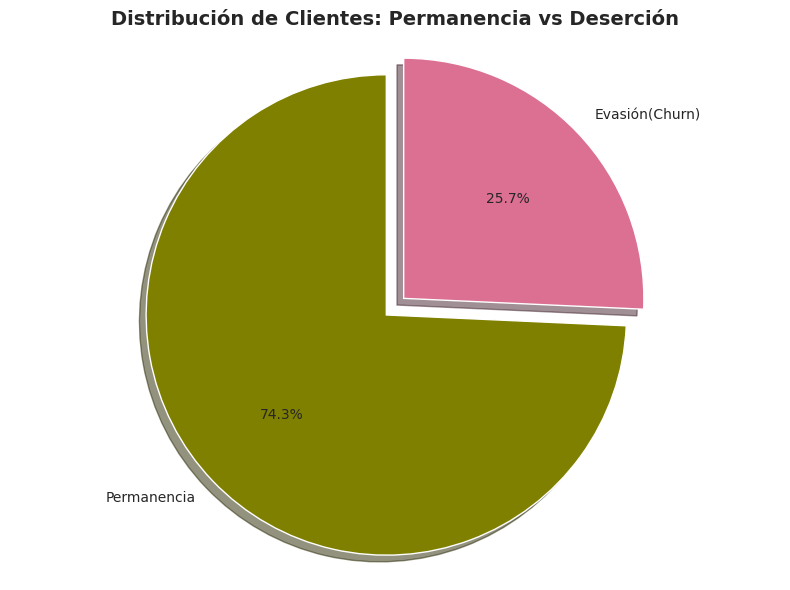

In [45]:
#FRECUENCIA ABSOLUTA Y RELATIVAS DE LA VARIABLE EVASIÓN
frequency = df['evasion'].value_counts().reset_index()
frequency.columns = ['evasion', 'cantidad']
frequency['porcentaje'] = (frequency['cantidad'] / frequency['cantidad'].sum()*100).round(1)


frequency['evasion'] = frequency['evasion'].map({0: 'Permanencia', 1: 'Evasión(Churn)'})

print(frequency.to_string(index=False))
print(f'\nTotal de clientes: {len(df)}')

plt.figure(figsize=(8, 6))
colores = ['olive', 'palevioletred']
plt.pie(frequency['cantidad'],
        labels=frequency['evasion'],
        autopct='%1.1f%%',
        colors=colores,
        startangle=90,
        explode=(0.05, 0.05),  # Separar ligeramente las rebanadas
        shadow=True)
plt.title('Distribución de Clientes: Permanencia vs Deserción', fontsize=14, fontweight='bold')
plt.axis('equal')  # Para que el pastel sea circular
plt.tight_layout()
plt.show()

Existe una de evasión (churn) del **25.7%** (1,869), el restante **74.3% **son clientes activos (5,398).

Valores únicos en 'Genero': ['Female' 'Male']

=== FRECUENCIAS ABSOLUTAS POR GÉNERO ===
        No evaden  Evaden  Total
Genero                          
Female       2653     939   3592
Male         2745     930   3675
All          5398    1869   7267

=== PORCENTAJES POR GÉNERO ===
        % No evaden  % Evaden
Genero                       
Female         73.9      26.1
Male           74.7      25.3


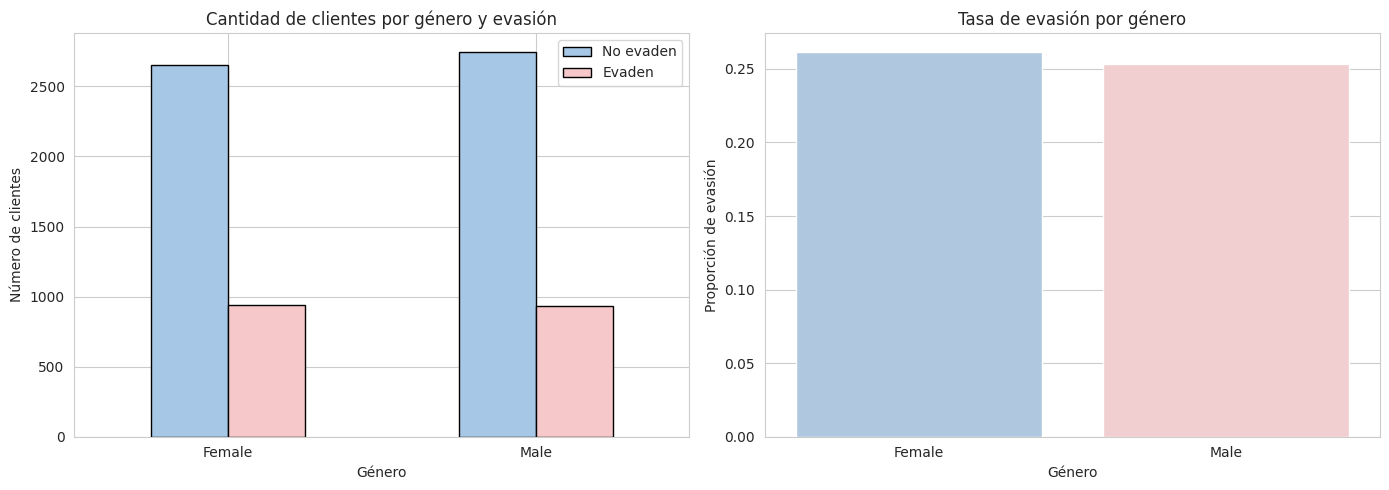

In [46]:
sns.set_style('whitegrid')

# Colores personalizados: baby blue y baby pink
colores_pastel = ['#A7C7E7', '#F7C8C9']  # baby blue, baby pink

# 1. Verificar valores únicos de género
print("Valores únicos en 'Genero':", df['Genero'].unique())

# 2. Tabla de contingencia: frecuencia absoluta
tabla_genero = pd.crosstab(df['Genero'], df['evasion'], margins=True)
tabla_genero.columns = ['No evaden', 'Evaden', 'Total']
print("\n=== FRECUENCIAS ABSOLUTAS POR GÉNERO ===")
print(tabla_genero)

# 3. Porcentajes por fila (dentro de cada género)
porcentaje_genero = pd.crosstab(df['Genero'], df['evasion'], normalize='index') * 100
porcentaje_genero.columns = ['% No evaden', '% Evaden']
print("\n=== PORCENTAJES POR GÉNERO ===")
print(porcentaje_genero.round(1))

# 4. Gráfico de barras agrupadas (frecuencia absoluta)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas (frecuencia absoluta)
df.groupby(['Genero', 'evasion']).size().unstack().plot(
    kind='bar', ax=axes[0], color=colores_pastel, edgecolor='black')
axes[0].set_title('Cantidad de clientes por género y evasión')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xlabel('Género')
axes[0].legend(['No evaden', 'Evaden'])
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de barras de tasas de evasión (corregido)
sns.barplot(data=df, x='Genero', y='evasion', ax=axes[1],
            hue='Genero', palette=colores_pastel, legend=False, errorbar=None)
axes[1].set_title('Tasa de evasión por género')
axes[1].set_ylabel('Proporción de evasión')
axes[1].set_xlabel('Género')

plt.tight_layout()
plt.show()

El **26.1%** de las clientes mujeres han evadido. El **25.3%** de los clientes hombres han evadido.

Valores únicos en 'Tipo_Contrato': ['One year' 'Month-to-month' 'Two year']

=== FRECUENCIAS ABSOLUTAS POR TIPO DE CONTRATO ===
                No evaden  Evaden  Total
Tipo_Contrato                           
Month-to-month       2350    1655   4005
One year             1353     166   1519
Two year             1695      48   1743
All                  5398    1869   7267

=== PORCENTAJES POR TIPO DE CONTRATO ===
                % No evaden  % Evaden
Tipo_Contrato                        
Month-to-month         58.7      41.3
One year               89.1      10.9
Two year               97.2       2.8


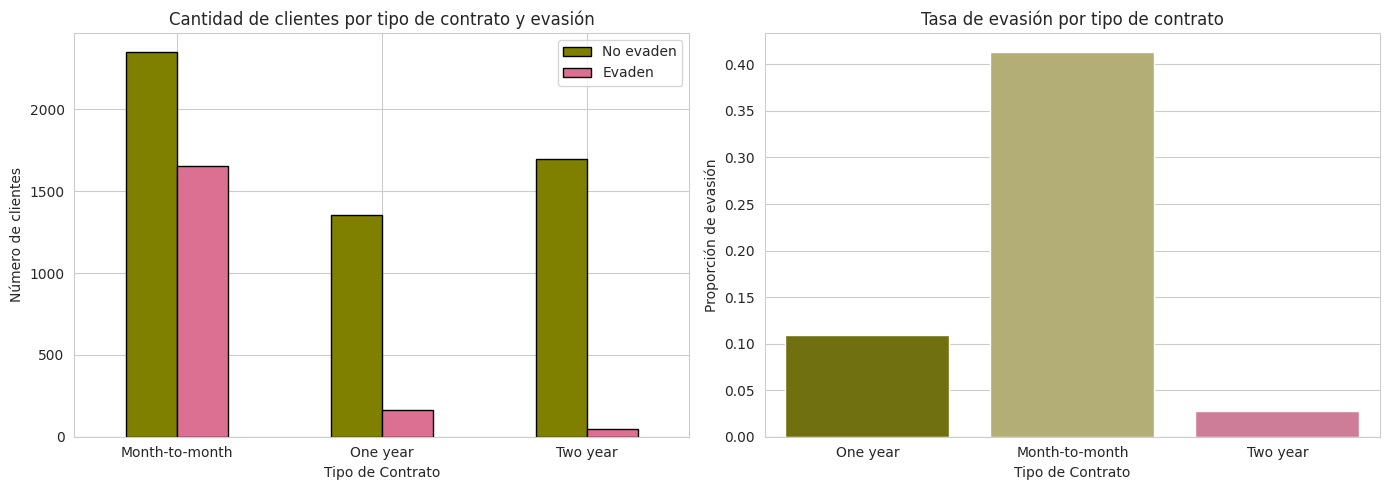

In [47]:
sns.set_style('whitegrid')

# Colores para el primer gráfico (barras agrupadas: No evaden / Evaden)
colores_barras_agrupadas = ['#808000', '#DB7093']  # oliva, palevioletred

# Colores para el segundo gráfico (tasa por categoría: tres colores)
# Opción 1: personalizados
colores_tres = ['#808000', '#BDB76B', '#DB7093']  # oliva, oliva claro, palevioletred
# Opción 2: usar una paleta de seaborn con 3 colores (descomenta la siguiente línea si prefieres)
# colores_tres = sns.color_palette('Set2', 3)

# 1. Verificar valores únicos
print("Valores únicos en 'Tipo_Contrato':", df['Tipo_Contrato'].unique())

# 2. Tabla de contingencia
tabla_contrato = pd.crosstab(df['Tipo_Contrato'], df['evasion'], margins=True)
tabla_contrato.columns = ['No evaden', 'Evaden', 'Total']
print("\n=== FRECUENCIAS ABSOLUTAS POR TIPO DE CONTRATO ===")
print(tabla_contrato)

# 3. Porcentajes
porcentaje_contrato = pd.crosstab(df['Tipo_Contrato'], df['evasion'], normalize='index') * 100
porcentaje_contrato.columns = ['% No evaden', '% Evaden']
print("\n=== PORCENTAJES POR TIPO DE CONTRATO ===")
print(porcentaje_contrato.round(1))

# 4. Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas (frecuencia absoluta)
df.groupby(['Tipo_Contrato', 'evasion']).size().unstack().plot(
    kind='bar', ax=axes[0], color=colores_barras_agrupadas, edgecolor='black')
axes[0].set_title('Cantidad de clientes por tipo de contrato y evasión')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xlabel('Tipo de Contrato')
axes[0].legend(['No evaden', 'Evaden'])
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de barras de tasas de evasión (corregido: con tres colores)
sns.barplot(data=df, x='Tipo_Contrato', y='evasion', ax=axes[1],
            hue='Tipo_Contrato', palette=colores_tres, legend=False, errorbar=None)
axes[1].set_title('Tasa de evasión por tipo de contrato')
axes[1].set_ylabel('Proporción de evasión')
axes[1].set_xlabel('Tipo de Contrato')

plt.tight_layout()
plt.show()

El **tipo de contrato mes por mes** es solicitado por 4,005 de los clientes, el 58.7% son clientes y el restante 41.3% son clientes que han evadido.

El **tipo de contrato de un año** es solicitado por 1,743 de los clientes, el 89.1% son clientes y el restante 10.9% son clientes que han evadido.

El **tipo de contrato de dos años** es solicitado por 1,519 de los clientes, el 97.2% son clientes y el restante 2.8% son clientes que han evadido.

Distribución porcentual de métodos de pago por grupo:
                           No evadieron (%)  Evadieron (%)
Metodo_Pago                                               
Bank transfer (automatic)              24.7           13.8
Credit card (automatic)                24.7           12.4
Electronic check                       25.5           57.3
Mailed check                           25.1           16.5


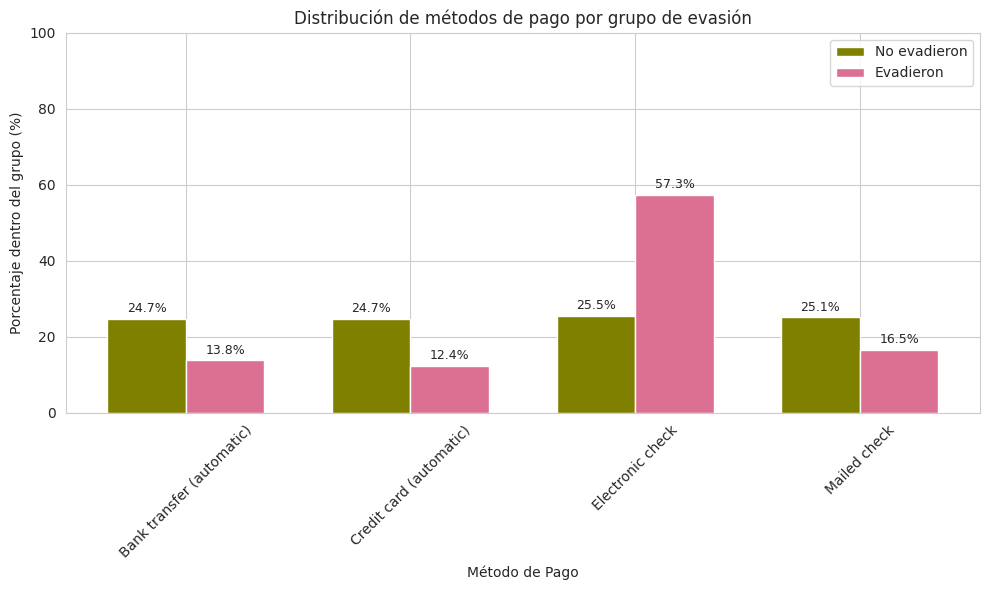

Valores únicos en 'Metodo_Pago': ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

=== FRECUENCIAS ABSOLUTAS POR MÉTODO DE PAGO ===
                           No evaden  Evaden  Total
Metodo_Pago                                        
Bank transfer (automatic)       1331     258   1589
Credit card (automatic)         1336     232   1568
Electronic check                1374    1071   2445
Mailed check                    1357     308   1665
All                             5398    1869   7267

=== PORCENTAJES POR MÉTODO DE PAGO ===
                           % No evaden  % Evaden
Metodo_Pago                                     
Bank transfer (automatic)         83.8      16.2
Credit card (automatic)           85.2      14.8
Electronic check                  56.2      43.8
Mailed check                      81.5      18.5


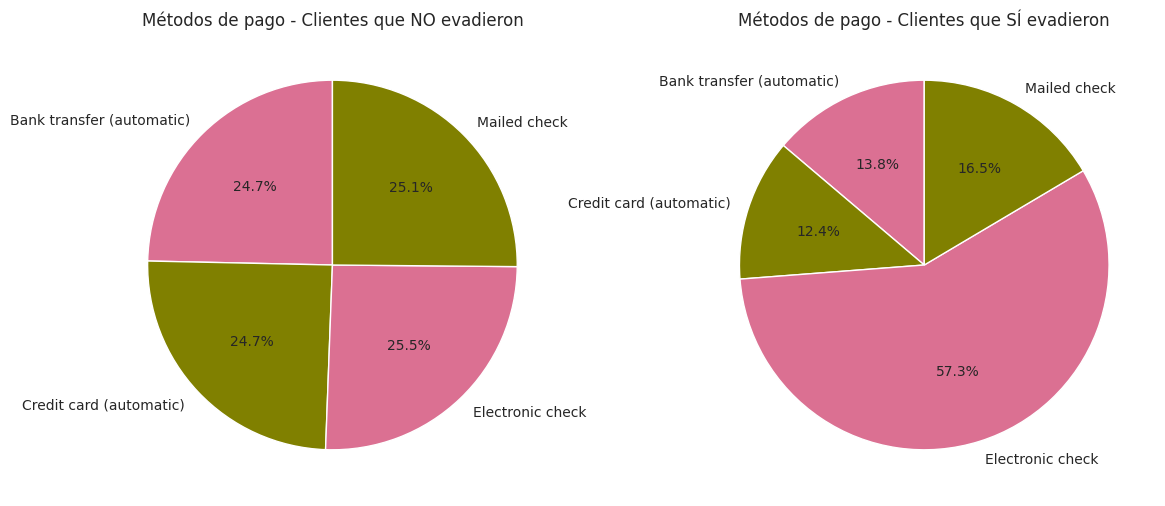

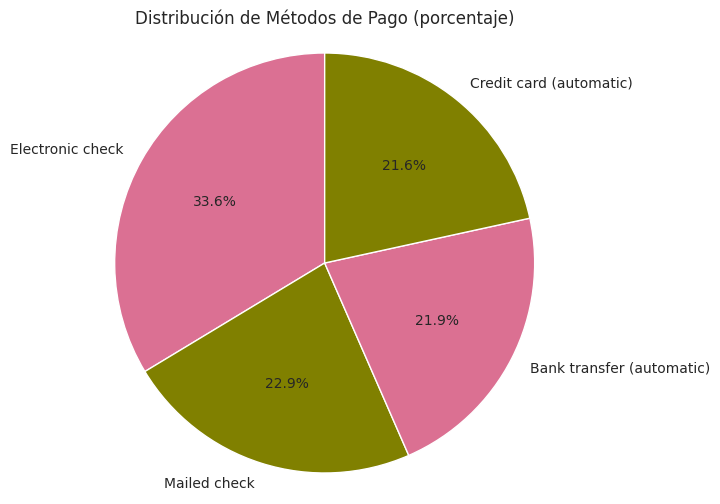

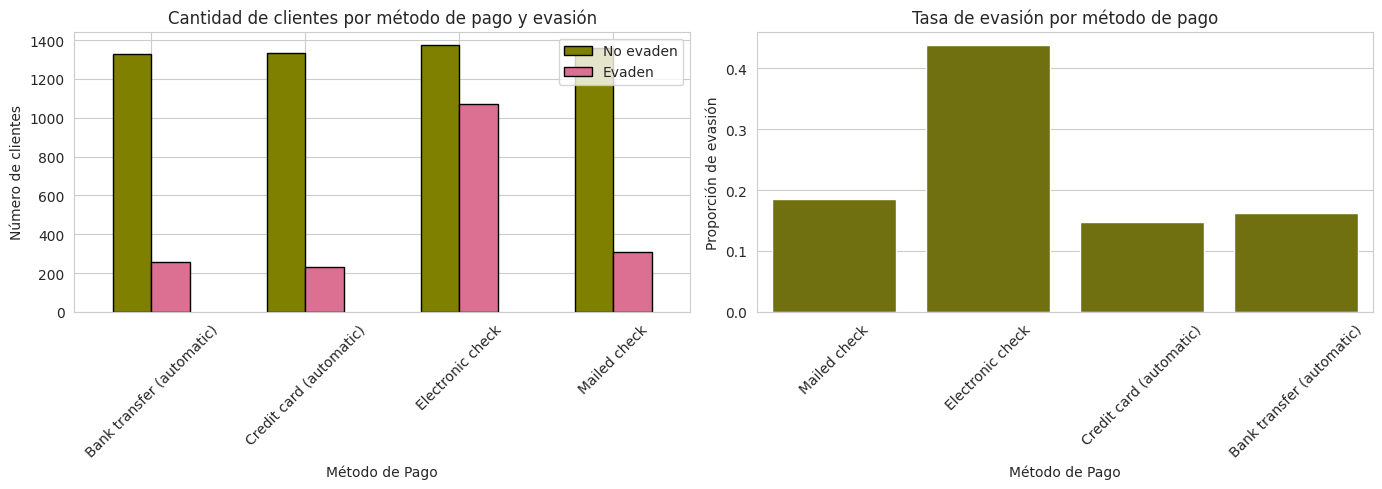

In [48]:
df['evasion'] = df['evasion'].astype(int)

# Tabla de contingencia: frecuencias absolutas
tabla = pd.crosstab(df['Metodo_Pago'], df['evasion'])
tabla.columns = ['No evadieron', 'Evadieron']

# Porcentajes por grupo (columna) – suma 100% en cada grupo
porc_no = (tabla['No evadieron'] / tabla['No evadieron'].sum()) * 100
porc_si  = (tabla['Evadieron'] / tabla['Evadieron'].sum()) * 100

# Mostrar tabla de porcentajes
print("Distribución porcentual de métodos de pago por grupo:")
print(pd.DataFrame({
    'No evadieron (%)': porc_no.round(1),
    'Evadieron (%)': porc_si.round(1)
}))

# ----- GRÁFICO DE BARRAS AGRUPADAS (porcentajes) -----
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(tabla.index))          # posiciones para cada método
width = 0.35

barras_no = ax.bar(x - width/2, porc_no, width, label='No evadieron', color='#808000')
barras_si  = ax.bar(x + width/2, porc_si, width, label='Evadieron', color='#DB7093')

ax.set_xlabel('Método de Pago')
ax.set_ylabel('Porcentaje dentro del grupo (%)')
ax.set_title('Distribución de métodos de pago por grupo de evasión')
ax.set_xticks(x)
ax.set_xticklabels(tabla.index, rotation=45)
ax.legend()
ax.set_ylim(0, 100)

# Añadir etiquetas con valores sobre las barras
for i, (no_val, si_val) in enumerate(zip(porc_no, porc_si)):
    ax.text(i - width/2, no_val + 1, f'{no_val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, si_val + 1, f'{si_val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ----- GRÁFICOS DE PASTEL LADO A LADO -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pastel para no evadieron
ax1.pie(porc_no, labels=porc_no.index, autopct='%1.1f%%', startangle=90,
        colors=['#DB7093','#808000','#DB7092','#808000'])
ax1.set_title('Métodos de pago - Clientes que NO evadieron')

# Pastel para evadieron
ax2.pie(porc_si, labels=porc_si.index, autopct='%1.1f%%', startangle=90,
        colors=['#DB7093','#808000','#DB7092','#808000'])
ax2.set_title('Métodos de pago - Clientes que SÍ evadieron')



#Tabla según método de pago
# ============================================
# ANÁLISIS DE EVASIÓN POR MÉTODO DE PAGO
# ============================================

sns.set_style('whitegrid')

# Colores para el gráfico de barras agrupadas (frecuencias)
colores_pago = ['#808000', '#DB7093']  # oliva (no evaden), palevioletred (evaden)

print("Valores únicos en 'Metodo_Pago':", df['Metodo_Pago'].unique())

# Tabla de contingencia
tabla_pago = pd.crosstab(df['Metodo_Pago'], df['evasion'], margins=True)
tabla_pago.columns = ['No evaden', 'Evaden', 'Total']
print("\n=== FRECUENCIAS ABSOLUTAS POR MÉTODO DE PAGO ===")
print(tabla_pago)

# Porcentajes por fila
porcentaje_pago = pd.crosstab(df['Metodo_Pago'], df['evasion'], normalize='index') * 100
porcentaje_pago.columns = ['% No evaden', '% Evaden']
print("\n=== PORCENTAJES POR MÉTODO DE PAGO ===")
print(porcentaje_pago.round(1))

# Gráfico de pastel (circular)
pago_counts = df['Metodo_Pago'].value_counts()
pago_percent = df['Metodo_Pago'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
plt.pie(pago_counts, labels=pago_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#DB7093','#808000','#DB7092','#808000'])
plt.title('Distribución de Métodos de Pago (porcentaje)')
plt.axis('equal')  # Para que el pastel sea circular
plt.show()

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras agrupadas (frecuencia absoluta)
df.groupby(['Metodo_Pago', 'evasion']).size().unstack().plot(
    kind='bar', ax=axes[0], color=colores_pago, edgecolor='black')
axes[0].set_title('Cantidad de clientes por método de pago y evasión')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xlabel('Método de Pago')
axes[0].legend(['No evaden', 'Evaden'])
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Tasa de evasión (sin hue, color único)
sns.barplot(data=df, x='Metodo_Pago', y='evasion', ax=axes[1],
            color='#808000', errorbar=None)  # un solo color (oliva)
axes[1].set_title('Tasa de evasión por método de pago')
axes[1].set_ylabel('Proporción de evasión')
axes[1].set_xlabel('Método de Pago')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

El **método de pago** más utilizado por los clientes es el **cheque electrónico** con un total de 1,357 clientes, donde el 43.8% evaden y el restante 56.2% ha permanecido.

El método de pago vía **cheque por correo** es usado por 1,357 clientes, donde el 18.5% evaden y el restante 81.5% ha permanecido.

El método de pago **automático por tarjeta de crédito** es usado por 1,336 clientes, donde el 14.8% evaden y el restante 85.2% ha permanecido.

El método de pago **automático por transferencia bancaria** es usado por 1,331 clientes, donde el 16.2% evaden y el restante 83.8% ha permanecido.

Valores únicos en 'Tipo_Internet': ['DSL' 'Fiber optic' 'No']

=== FRECUENCIAS ABSOLUTAS POR TIPO DE INTERNET ===
               No evaden  Evaden  Total
Tipo_Internet                          
DSL                 2029     459   2488
Fiber optic         1901    1297   3198
No                  1468     113   1581
All                 5398    1869   7267

=== PORCENTAJES POR TIPO DE INTERNET ===
               % No evaden  % Evaden
Tipo_Internet                       
DSL                   81.6      18.4
Fiber optic           59.4      40.6
No                    92.9       7.1


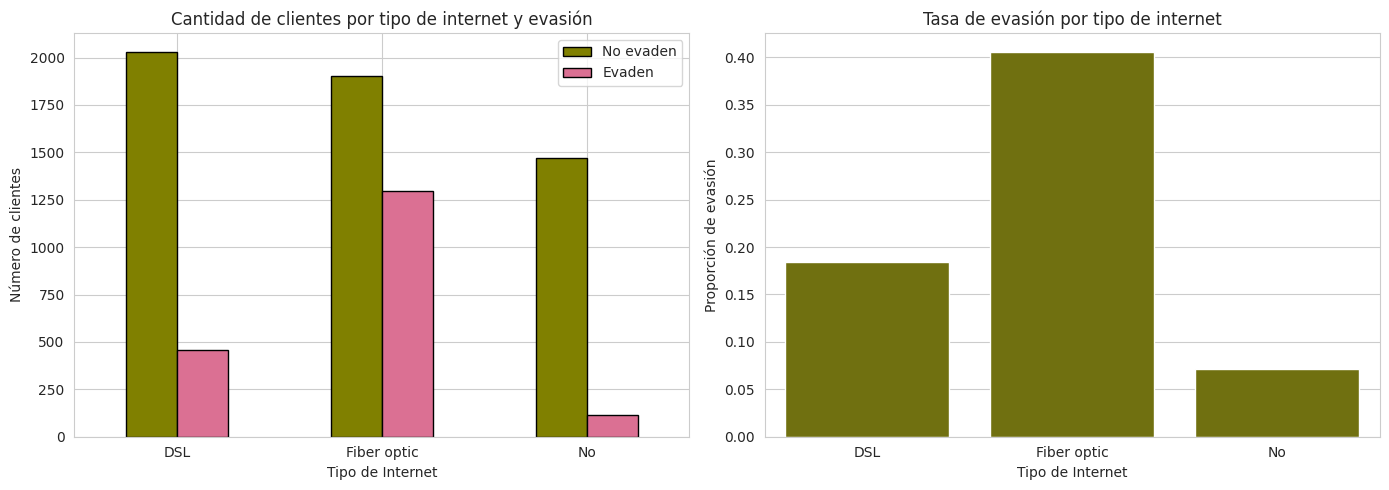

In [49]:
# ============================================
# ANÁLISIS DE EVASIÓN POR TIPO DE INTERNET
# ============================================

sns.set_style('whitegrid')

# Colores: oliva (no evaden) y palevioletred (evaden) para el gráfico de barras agrupadas
colores_internet = ['#808000', '#DB7093']

# 1. Verificar valores únicos
print("Valores únicos en 'Tipo_Internet':", df['Tipo_Internet'].unique())

# 2. Tabla de contingencia: frecuencias absolutas
tabla_internet = pd.crosstab(df['Tipo_Internet'], df['evasion'], margins=True)
tabla_internet.columns = ['No evaden', 'Evaden', 'Total']
print("\n=== FRECUENCIAS ABSOLUTAS POR TIPO DE INTERNET ===")
print(tabla_internet)

# 3. Porcentajes por fila (dentro de cada tipo de internet)
porcentaje_internet = pd.crosstab(df['Tipo_Internet'], df['evasion'], normalize='index') * 100
porcentaje_internet.columns = ['% No evaden', '% Evaden']
print("\n=== PORCENTAJES POR TIPO DE INTERNET ===")
print(porcentaje_internet.round(1))

# 4. Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas (frecuencia absoluta)
df.groupby(['Tipo_Internet', 'evasion']).size().unstack().plot(
    kind='bar', ax=axes[0], color=colores_internet, edgecolor='black')
axes[0].set_title('Cantidad de clientes por tipo de internet y evasión')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xlabel('Tipo de Internet')
axes[0].legend(['No evaden', 'Evaden'])
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de barras de tasas de evasión (color único oliva)
sns.barplot(data=df, x='Tipo_Internet', y='evasion', ax=axes[1],
            color='#808000', errorbar=None, order=['DSL', 'Fiber optic', 'No'])
axes[1].set_title('Tasa de evasión por tipo de internet')
axes[1].set_ylabel('Proporción de evasión')
axes[1].set_xlabel('Tipo de Internet')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

El **tipo de  internet** más utilizado por los clientes es la **fibra óptica**, con un total de **3,198** usuarios(donde 1,901 son clientes activos y el restante 1,297 son clientes que han evadido), sin embargo, el tipo de internet más utilizado por clientes que aún permanenecen es el **DSL** (Línea de Suscriptor Digital) con un total de **2,029 **clientes activos, solo 459 de estos clientes han evadido.

Los restante 1,581 clientes **no tienen internet**, donde el 92.9% (1468) han permanecido y el restante 7.1% (113) ha evadido.

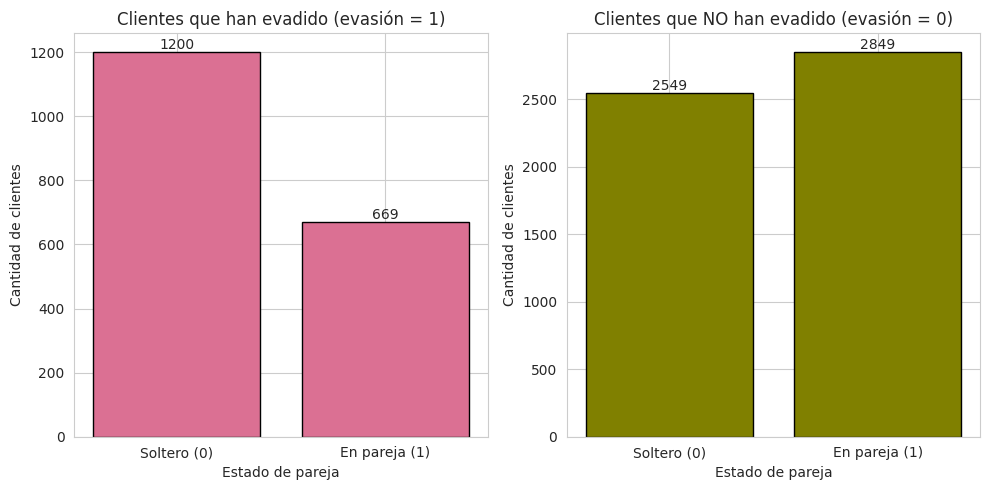

In [50]:
df['En_Pareja'] = df['En_Pareja'].astype(int)
df['evasion'] = df['evasion'].astype(int)

# Calcular conteos
conteos = df.groupby(['En_Pareja', 'evasion']).size().unstack(fill_value=0)

# Etiquetas
etiquetas_pareja = ['Soltero (0)', 'En pareja (1)']
colores = ['#808000', '#DB7093']  # oliva para no evaden, palevioletred para evaden

# Crear figura con dos subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Subplot 1: Evadidos (evasion = 1)
ax1.bar(etiquetas_pareja, conteos[1], color=colores[1], edgecolor='black')
ax1.set_title('Clientes que han evadido (evasión = 1)')
ax1.set_ylabel('Cantidad de clientes')
ax1.set_xlabel('Estado de pareja')
ax1.bar_label(ax1.containers[0])  # mostrar valores sobre las barras

# Subplot 2: No evadidos (evasion = 0)
ax2.bar(etiquetas_pareja, conteos[0], color=colores[0], edgecolor='black')
ax2.set_title('Clientes que NO han evadido (evasión = 0)')
ax2.set_ylabel('Cantidad de clientes')
ax2.set_xlabel('Estado de pareja')
ax2.bar_label(ax2.containers[0])

plt.tight_layout()
plt.show()

Existe un total de **3,749 solteros**, de los cuales **1200** corresponden a clientes que** evadiero**n y el restante **2,549 ha permanecido**. Por otra parte hay **3,518 en pareja**, de los cuales 669 ha evadido y el restante **2,849 ha permanecido**.

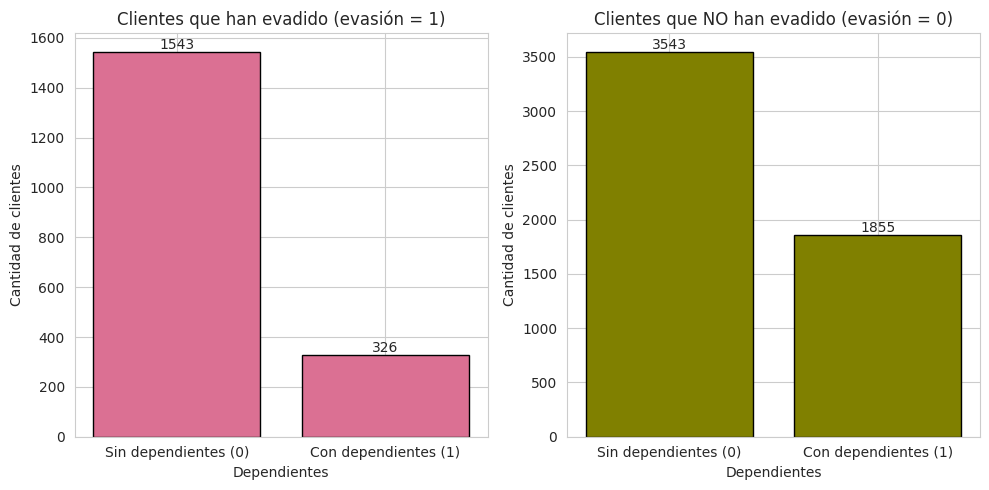

In [51]:
df['Dependientes'] = df['Dependientes'].astype(int)
df['evasion'] = df['evasion'].astype(int)

# Calcular conteos
conteos_dep = df.groupby(['Dependientes', 'evasion']).size().unstack(fill_value=0)

# Etiquetas
etiquetas_dep = ['Sin dependientes (0)', 'Con dependientes (1)']
colores = ['#808000', '#DB7093']  # oliva para no evaden, palevioletred para evaden

# Crear figura con dos subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Subplot 1: Evadidos (evasion = 1)
ax1.bar(etiquetas_dep, conteos_dep[1], color=colores[1], edgecolor='black')
ax1.set_title('Clientes que han evadido (evasión = 1)')
ax1.set_ylabel('Cantidad de clientes')
ax1.set_xlabel('Dependientes')
ax1.bar_label(ax1.containers[0])  # muestra los valores sobre las barras

# Subplot 2: No evadidos (evasion = 0)
ax2.bar(etiquetas_dep, conteos_dep[0], color=colores[0], edgecolor='black')
ax2.set_title('Clientes que NO han evadido (evasión = 0)')
ax2.set_ylabel('Cantidad de clientes')
ax2.set_xlabel('Dependientes')
ax2.bar_label(ax2.containers[0])

plt.tight_layout()
plt.show()

Hay **2,181** clientes **con dependientes**, de los cuales **326 ha evadido** y el restante **1,855 ha permanecid**o. Mientras que hay **5,086 clientes sin dependientes**, de los cuales **1,543 ha evadido** y el restante **3,543 ha permanecido**.

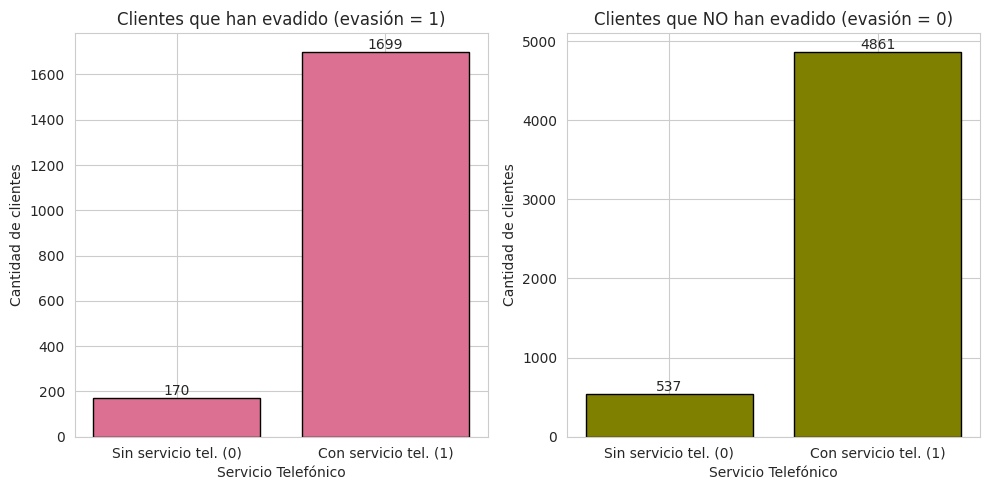

In [52]:
df['Servicio_Telefonico'] = df['Servicio_Telefonico'].astype(int)
df['evasion'] = df['evasion'].astype(int)

# Calcular conteos
conteos_tel = df.groupby(['Servicio_Telefonico', 'evasion']).size().unstack(fill_value=0)

# Etiquetas
etiquetas_tel = ['Sin servicio tel. (0)', 'Con servicio tel. (1)']
colores = ['#808000', '#DB7093']  # oliva para no evaden, palevioletred para evaden

# Crear figura con dos subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Subplot 1: Evadidos (evasion = 1)
ax1.bar(etiquetas_tel, conteos_tel[1], color=colores[1], edgecolor='black')
ax1.set_title('Clientes que han evadido (evasión = 1)')
ax1.set_ylabel('Cantidad de clientes')
ax1.set_xlabel('Servicio Telefónico')
ax1.bar_label(ax1.containers[0])  # muestra los valores sobre las barras

# Subplot 2: No evadidos (evasion = 0)
ax2.bar(etiquetas_tel, conteos_tel[0], color=colores[0], edgecolor='black')
ax2.set_title('Clientes que NO han evadido (evasión = 0)')
ax2.set_ylabel('Cantidad de clientes')
ax2.set_xlabel('Servicio Telefónico')
ax2.bar_label(ax2.containers[0])

plt.tight_layout()
plt.show()

Solo **707 clientes** que **no** tienen contratado el s **servicio telefónico**, **170** son clientes que** han evadido** y el restante **537 ha permanecido**. Por otro lado **6,560 clientes si posee** el servicio telefónico, donde **4,861 ha permanecido** y el restante **1,699 ha evadido.**

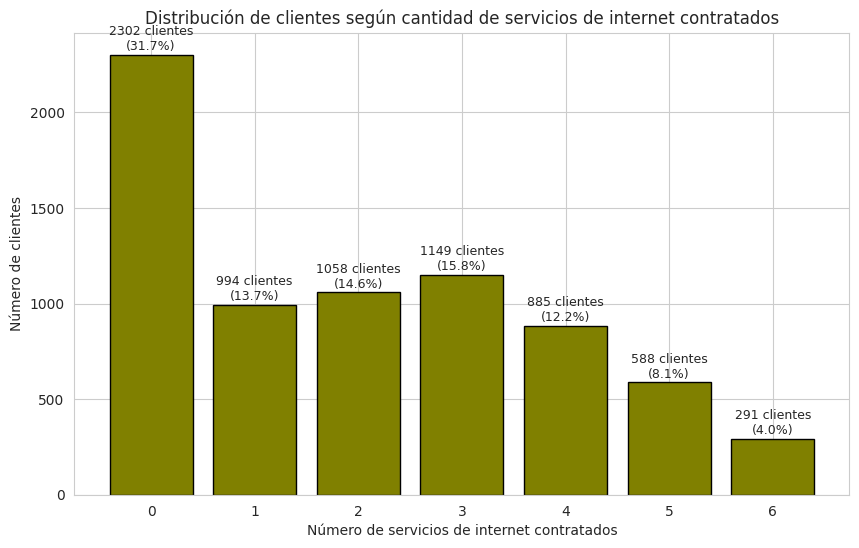

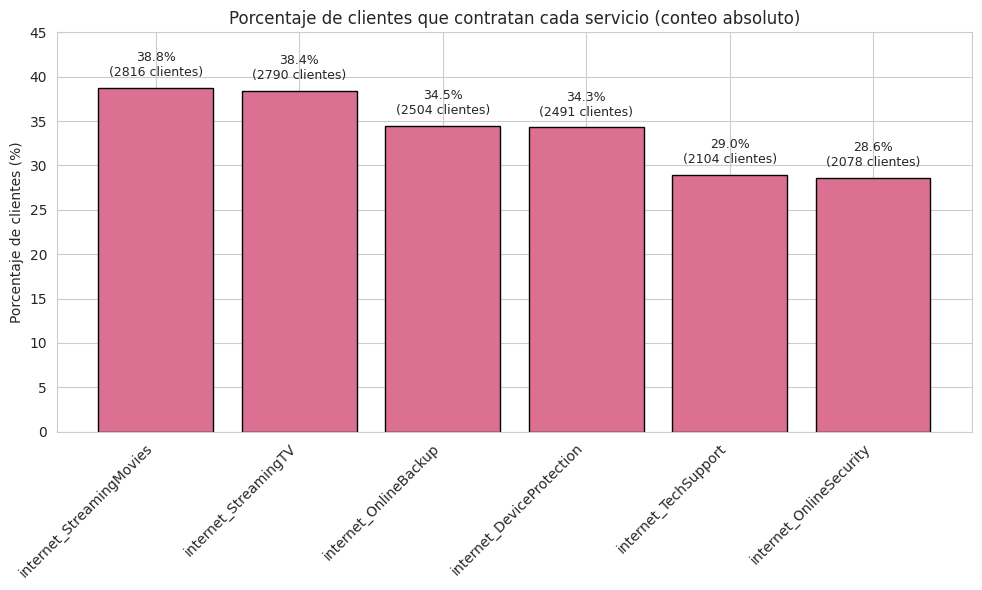

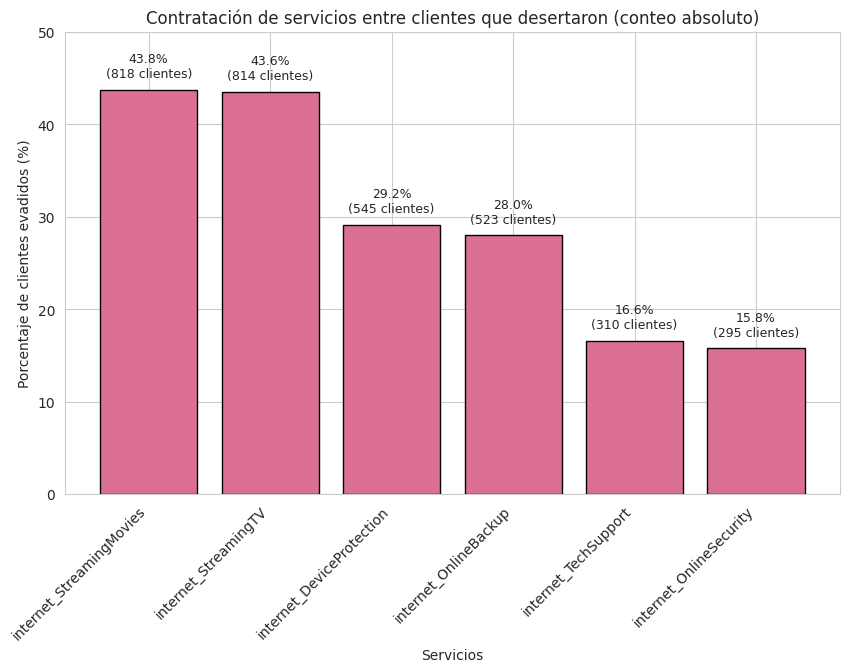

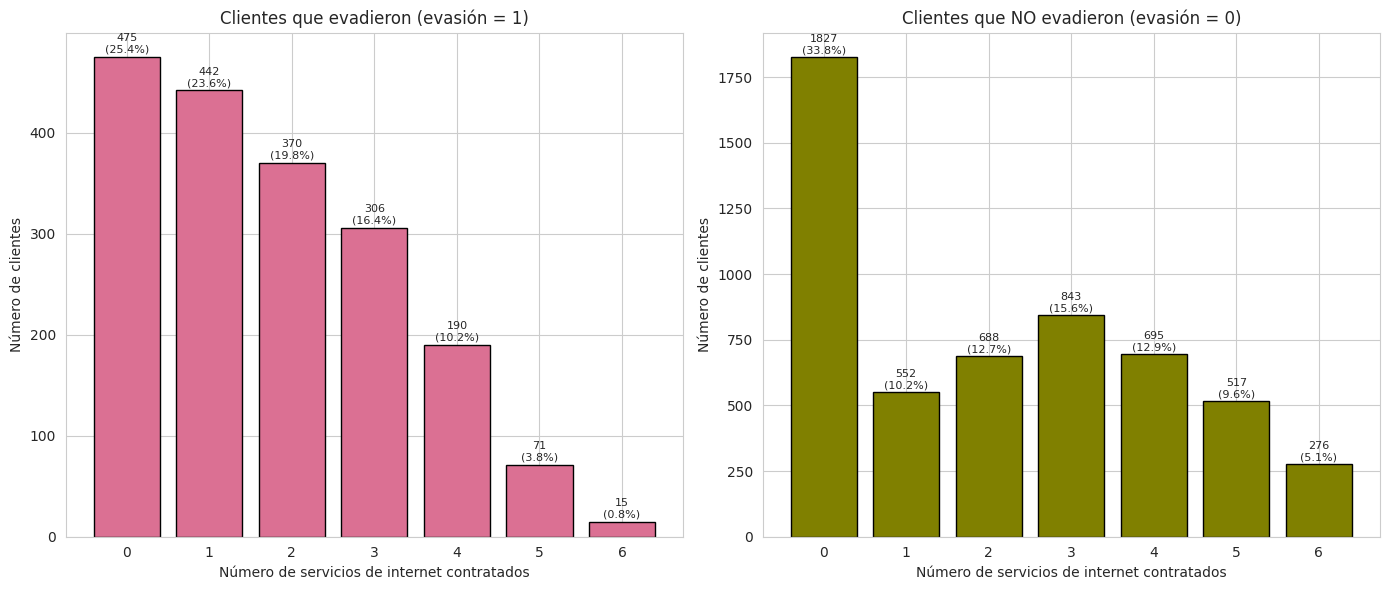

In [65]:
# Lista de servicios
servicios = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport',
    'internet_StreamingTV',
    'internet_StreamingMovies'
]


for col in servicios:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Crear columna con el total de servicios contratados por cliente
df['total_servicios'] = df[servicios].sum(axis=1)

# Contar cuántos clientes tienen cada cantidad (de 0 a 6)
conteo = df['total_servicios'].value_counts().sort_index()

# Asegurar que aparezcan todos los valores del 0 al 6 (rellenar con 0 si falta)
for i in range(7):
    if i not in conteo.index:
        conteo[i] = 0
conteo = conteo.sort_index()

# Calcular porcentajes
total_clientes = len(df)
porcentajes = (conteo / total_clientes) * 100

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
barras = plt.bar(conteo.index.astype(str), conteo.values, color='#808000', edgecolor='black')
plt.xlabel('Número de servicios de internet contratados')
plt.ylabel('Número de clientes')
plt.title('Distribución de clientes según cantidad de servicios de internet contratados')

# Añadir etiquetas con neto y porcentaje sobre cada barra
for barra, neto, pct in zip(barras, conteo.values, porcentajes.values):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 10,
             f'{neto} clientes\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9)


# ----- GRÁFICO 1 (total de clientes) -----
# Calcular porcentaje y conteo absoluto para cada servicio
porcentajes_total = (df[servicios].mean() * 100).sort_values(ascending=False)
conteos_total = df[servicios].sum().loc[porcentajes_total.index]  # mismo orden

plt.figure(figsize=(10, 6))
barras = plt.bar(porcentajes_total.index, porcentajes_total.values, color='#DB7093', edgecolor='black')
plt.ylabel('Porcentaje de clientes (%)')
plt.title('Porcentaje de clientes que contratan cada servicio (conteo absoluto)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 45)

# Añadir etiquetas con porcentaje y número de clientes
for barra, (serv, porc, cont) in zip(barras, zip(porcentajes_total.index, porcentajes_total.values, conteos_total)):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 1,
             f'{porc:.1f}%\n({int(cont)} clientes)',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ----- GRÁFICO 2 (clientes que evadieron) -----
df_evadidos = df[df['evasion'] == 1]
total_evadidos = len(df_evadidos)

# Calcular porcentaje y conteo absoluto para cada servicio
porcentajes = (df_evadidos[servicios].mean() * 100).sort_values(ascending=False)
conteos = df_evadidos[servicios].sum().loc[porcentajes.index]  # mismo orden

plt.figure(figsize=(10, 6))
barras = plt.bar(porcentajes.index, porcentajes.values, color='#DB7093', edgecolor='black')
plt.ylabel('Porcentaje de clientes evadidos (%)')
plt.xlabel('Servicios')
plt.title('Contratación de servicios entre clientes que desertaron (conteo absoluto)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 50)

# Añadir etiquetas con porcentaje y número de clientes
for barra, (serv, porc, cont) in zip(barras, zip(porcentajes.index, porcentajes.values, conteos)):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 1,
             f'{porc:.1f}%\n({int(cont)} clientes)',
             ha='center', va='bottom', fontsize=9)

#cantidad de serv

for col in servicios:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Crear columna con total de servicios por cliente
df['total_servicios'] = df[servicios].sum(axis=1)

# Separar grupos según evasión
evadidos = df[df['evasion'] == 1]
no_evadidos = df[df['evasion'] == 0]

# Función para obtener conteos y porcentajes completos (0 a 6)
def get_counts_and_percents(subset):
    conteo = subset['total_servicios'].value_counts().sort_index()
    # Asegurar que aparezcan todos los valores del 0 al 6
    for i in range(7):
        if i not in conteo.index:
            conteo[i] = 0
    conteo = conteo.sort_index()
    total = len(subset)
    porcentajes = (conteo / total) * 100
    return conteo, porcentajes

# Obtener datos para cada grupo
conteo_ev, pct_ev = get_counts_and_percents(evadidos)
conteo_no, pct_no = get_counts_and_percents(no_evadidos)

# Crear figura con dos subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico para clientes que evadieron
x = np.arange(7)  # 0 a 6
barras1 = ax1.bar(x, conteo_ev.values, color='#DB7093', edgecolor='black')
ax1.set_xlabel('Número de servicios de internet contratados')
ax1.set_ylabel('Número de clientes')
ax1.set_title('Clientes que evadieron (evasión = 1)')
ax1.set_xticks(x)
ax1.set_xticklabels([str(i) for i in range(7)])

# Añadir etiquetas con neto y porcentaje sobre cada barra
for barra, neto, pct in zip(barras1, conteo_ev.values, pct_ev.values):
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2, altura + 2,
             f'{neto}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=8)

# Gráfico para clientes que NO evadieron
barras2 = ax2.bar(x, conteo_no.values, color='#808000', edgecolor='black')
ax2.set_xlabel('Número de servicios de internet contratados')
ax2.set_ylabel('Número de clientes')
ax2.set_title('Clientes que NO evadieron (evasión = 0)')
ax2.set_xticks(x)
ax2.set_xticklabels([str(i) for i in range(7)])

for barra, neto, pct in zip(barras2, conteo_no.values, pct_no.values):
    altura = barra.get_height()
    ax2.text(barra.get_x() + barra.get_width()/2, altura + 5,
             f'{neto}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=8)



plt.tight_layout()
plt.show()

Un total de** 2,302** clientes suele contratar **0** tipos de servicios adicionales de internet. Una cantidad de **994** clientes suele contratar **1** tipos de servicios adicionales de internet. Son **1,058** clientes suele contratar **2** tipos de servicios adicionales de internet.  Entre **1,149** clientes suele contratar **3** tipos de servicios adicionales de internet. Son **885** clientes suele contratar **4** tipos de servicios adicionales de internet. Una cantidad de **588** clientes suele contratar **5** tipos de servicios adicionales de internet. Y finalmente, **291** clientes suele contratar **6** tipos de servicios adicionales de internet.


El **internet_StreamingMovies** es contratado por el **38.8% **de los clientes. El **43.8%** de los clientes que evadieron habían contratado este servicio.


El **internet_StreamingTV** es contratado por el **38.4%** de los clientes. El **43.6%** de los clientes que evadieron habían contratado este servicio.


El **internet_OnlineBackup** es contratado por el **34.5%** de los clientes. El **29.2%** de los clientes que evadieron habían contratado este servicio.


El **internet_DeviceProtection** es contratado por el **34.3%** de los clientes. El **28.0%** de los clientes que evadieron habían contratado este servicio.


El **internet_TechSupport** es contratado por el **29.0%** de los clientes. El **16.6%** de los clientes que evadieron habían contratado este servicio.


El **internet_OnlineSecurity** es contratado por el **28.6%** de los clientes. El **15.8%** de los clientes que evadieron habían contratado este servicio.


Entre los clientes que evadieron **25.4%** habían contratado **0/6** servicios, el **23.6%** contrataron **1/6** servicio, el **19.8%** contrataron **2/6** servicios, el **16.4%** contrataron **3/6** servicios, el **10.2%** contrataron **4/6** servicios, el **3.8%** contrataron **5/6** servicios, y finalmente entre los clientes que han evadido, el **0.8%** habían contratado **6/6** servicios.


Por otro lado, entre los clientes que permanecieron **33.8%** habían contratado **0/6** servicios, el **10.2%** contrataron **1/6** servicio, el **12.7%** contrataron **2/6** servicios, el **15.6%** contrataron **3/6** servicios, el **12.9%** contrataron **4/6** servicios, el **9.6%** contrataron **5/6** servicios, y finalmente entre los clientes que han permanecido,  el **5.1%** habían contratado **6/6** servicios.

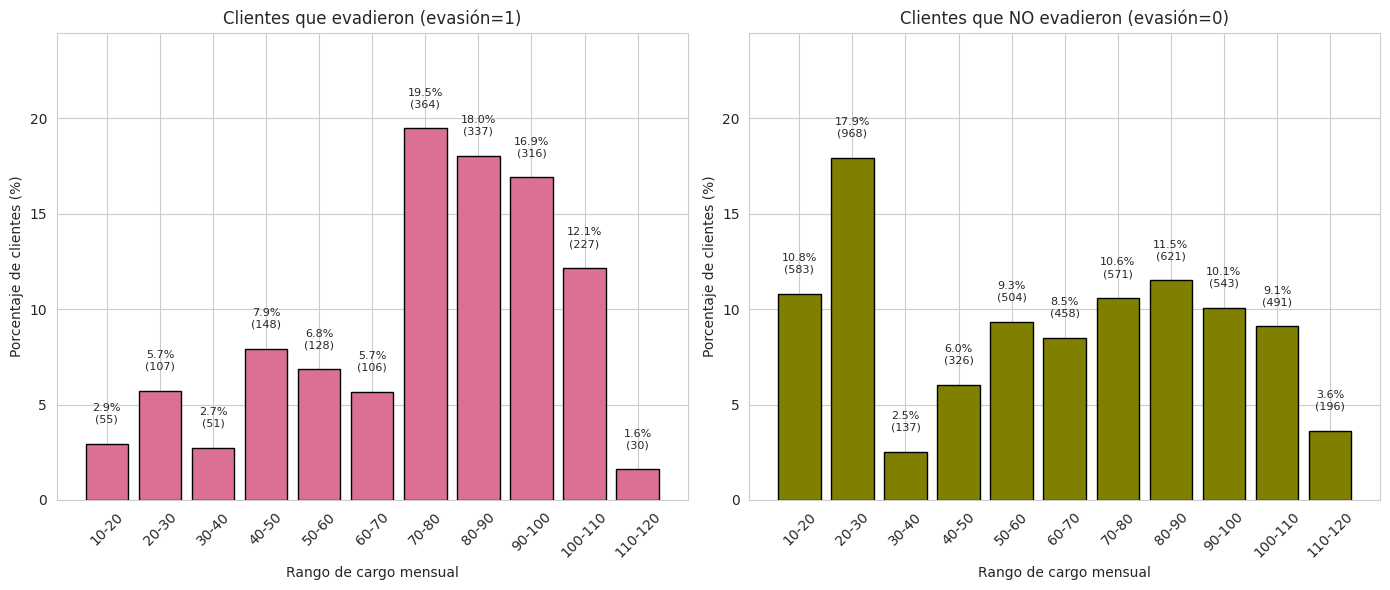

In [54]:
bins = np.arange(10, 130, 10)  # de 10 a 120, cada 10
labels = [f'{i}-{i+10}' for i in range(10, 120, 10)]

# Crear columna de rangos
df['rango_cargo'] = pd.cut(df['Cargo_Mensual'], bins=bins, labels=labels, right=False)

# Separar grupos
evadidos = df[df['evasion'] == 1]
no_evadidos = df[df['evasion'] == 0]

# Calcular distribuciones
dist_evadidos = evadidos['rango_cargo'].value_counts().sort_index()
dist_no_evadidos = no_evadidos['rango_cargo'].value_counts().sort_index()

# Porcentajes dentro de cada grupo
pct_evadidos = (dist_evadidos / len(evadidos)) * 100
pct_no_evadidos = (dist_no_evadidos / len(no_evadidos)) * 100

# Asegurar que todos los rangos aparezcan (rellenar con 0 si falta)
for rango in labels:
    if rango not in dist_evadidos.index:
        dist_evadidos[rango] = 0
        pct_evadidos[rango] = 0
    if rango not in dist_no_evadidos.index:
        dist_no_evadidos[rango] = 0
        pct_no_evadidos[rango] = 0

# Ordenar por rango
dist_evadidos = dist_evadidos.sort_index()
pct_evadidos = pct_evadidos.sort_index()
dist_no_evadidos = dist_no_evadidos.sort_index()
pct_no_evadidos = pct_no_evadidos.sort_index()

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico para evadidos
barras1 = ax1.bar(range(len(labels)), pct_evadidos.values, color='#DB7093', edgecolor='black')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel('Porcentaje de clientes (%)')
ax1.set_xlabel('Rango de cargo mensual')
ax1.set_title('Clientes que evadieron (evasión=1)')
ax1.set_ylim(0, max(pct_evadidos.max(), pct_no_evadidos.max()) + 5)

# Etiquetas con porcentaje y neto
for i, (barra, pct, neto) in enumerate(zip(barras1, pct_evadidos.values, dist_evadidos.values)):
    altura = barra.get_height()
    ax1.text(i, altura + 1, f'{pct:.1f}%\n({neto})', ha='center', va='bottom', fontsize=8)

# Gráfico para no evadidos
barras2 = ax2.bar(range(len(labels)), pct_no_evadidos.values, color='#808000', edgecolor='black')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45)
ax2.set_ylabel('Porcentaje de clientes (%)')
ax2.set_xlabel('Rango de cargo mensual')
ax2.set_title('Clientes que NO evadieron (evasión=0)')
ax2.set_ylim(0, max(pct_evadidos.max(), pct_no_evadidos.max()) + 5)

for i, (barra, pct, neto) in enumerate(zip(barras2, pct_no_evadidos.values, dist_no_evadidos.values)):
    altura = barra.get_height()
    ax2.text(i, altura + 1, f'{pct:.1f}%\n({neto})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

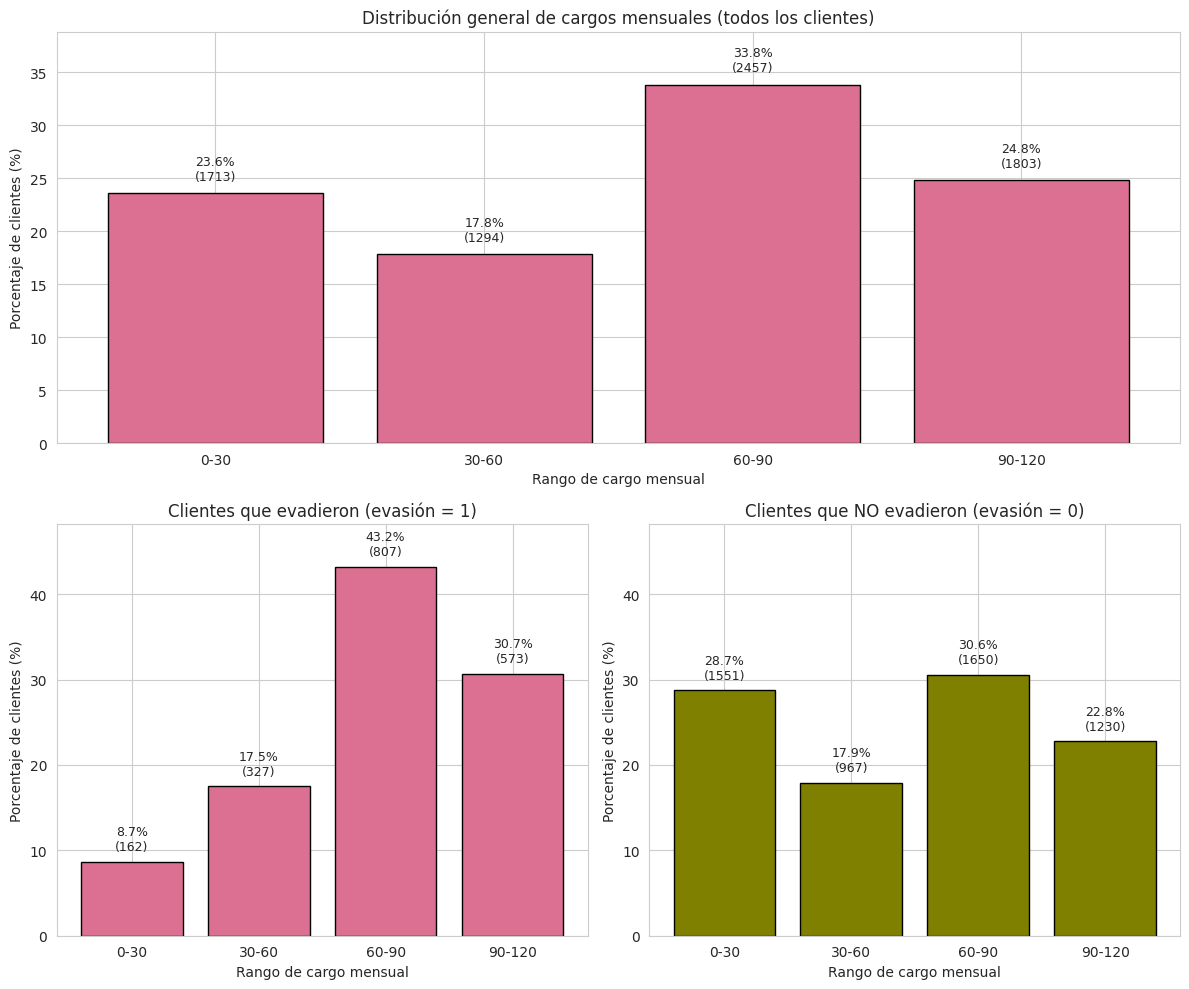

In [55]:
# --- Preparación de datos: rangos de cargo mensual ---
bins = [0, 30, 60, 90, 120]
labels = ['0-30', '30-60', '60-90', '90-120']
df['rango_cargo'] = pd.cut(df['Cargo_Mensual'], bins=bins, labels=labels, right=False, include_lowest=True)

# --- Distribución general (todos los clientes) ---
total_clientes = len(df)
general_counts = df['rango_cargo'].value_counts().sort_index()
general_pct = (general_counts / total_clientes) * 100

# Asegurar que todos los rangos estén presentes
for rango in labels:
    if rango not in general_counts.index:
        general_counts[rango] = 0
        general_pct[rango] = 0
general_counts = general_counts.sort_index()
general_pct = general_pct.sort_index()

# --- Separar por evasión ---
evadidos = df[df['evasion'] == 1]
no_evadidos = df[df['evasion'] == 0]

# Frecuencias absolutas por rango
dist_ev = evadidos['rango_cargo'].value_counts().sort_index()
dist_no = no_evadidos['rango_cargo'].value_counts().sort_index()

# Porcentajes dentro de cada grupo
pct_ev = (dist_ev / len(evadidos)) * 100
pct_no = (dist_no / len(no_evadidos)) * 100

# Rellenar rangos faltantes
for rango in labels:
    if rango not in dist_ev.index:
        dist_ev[rango] = 0
        pct_ev[rango] = 0
    if rango not in dist_no.index:
        dist_no[rango] = 0
        pct_no[rango] = 0

dist_ev = dist_ev.sort_index()
pct_ev = pct_ev.sort_index()
dist_no = dist_no.sort_index()
pct_no = pct_no.sort_index()

# --- Crear figura con 3 subplots (top + dos abajo) ---
fig = plt.figure(figsize=(12, 10))
ax_top = plt.subplot2grid((2, 2), (0, 0), colspan=2)          # Gráfico general arriba
ax_bottom_left = plt.subplot2grid((2, 2), (1, 0))             # Evadidos abajo izquierda
ax_bottom_right = plt.subplot2grid((2, 2), (1, 1))            # No evadidos abajo derecha

# --- Gráfico superior: distribución general ---
x = np.arange(len(labels))
barras_top = ax_top.bar(x, general_pct.values, color='#DB7093', edgecolor='black')
ax_top.set_xticks(x)
ax_top.set_xticklabels(labels)
ax_top.set_ylabel('Porcentaje de clientes (%)')
ax_top.set_xlabel('Rango de cargo mensual')
ax_top.set_title('Distribución general de cargos mensuales (todos los clientes)')
ax_top.set_ylim(0, max(general_pct) + 5)

for i, (pct, cnt) in enumerate(zip(general_pct.values, general_counts.values)):
    ax_top.text(i, pct + 1, f'{pct:.1f}%\n({int(cnt)})', ha='center', va='bottom', fontsize=9)

# --- Gráfico inferior izquierdo: evadidos ---
barras_ev = ax_bottom_left.bar(x, pct_ev.values, color='#DB7093', edgecolor='black')
ax_bottom_left.set_xticks(x)
ax_bottom_left.set_xticklabels(labels)
ax_bottom_left.set_ylabel('Porcentaje de clientes (%)')
ax_bottom_left.set_xlabel('Rango de cargo mensual')
ax_bottom_left.set_title('Clientes que evadieron (evasión = 1)')
ax_bottom_left.set_ylim(0, max(pct_ev.max(), pct_no.max()) + 5)

for i, (pct, cnt) in enumerate(zip(pct_ev.values, dist_ev.values)):
    ax_bottom_left.text(i, pct + 1, f'{pct:.1f}%\n({int(cnt)})', ha='center', va='bottom', fontsize=9)

# --- Gráfico inferior derecho: no evadidos ---
barras_no = ax_bottom_right.bar(x, pct_no.values, color='#808000', edgecolor='black')
ax_bottom_right.set_xticks(x)
ax_bottom_right.set_xticklabels(labels)
ax_bottom_right.set_ylabel('Porcentaje de clientes (%)')
ax_bottom_right.set_xlabel('Rango de cargo mensual')
ax_bottom_right.set_title('Clientes que NO evadieron (evasión = 0)')
ax_bottom_right.set_ylim(0, max(pct_ev.max(), pct_no.max()) + 5)

for i, (pct, cnt) in enumerate(zip(pct_no.values, dist_no.values)):
    ax_bottom_right.text(i, pct + 1, f'{pct:.1f}%\n({int(cnt)})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

El **23.6%** de los clientes corresponde a un **cargo mensual** entre **0-30 dólares**, el **17.8%** de los clientes corresponde a un cargo mensual entre **30-60 dólares**, el **33.8%** de los clientes corresponde a un cargo mensual entre **60-90** **dólares**, el **24.8%** de los clientes corresponde a un cargo mensual entre **90-120** **dólares**.

Centrandonos en los clientes que evadieron, el **8.7%** de los **desertores** tenían un cargo mensual entre **0-30 dólares**, el **17.5%** de los desertores tenían un cargo mensual entre **30-60 dólares**, el **43.2%** de los desertores tenían un cargo mensual entre **60-90 dólares**, el **30.7%** de los desertores tenían un cargo mensual entre **90-120 dólares**.

Entre los clientes activos, el **28.7%** de los **activos** poseen un cargo mensual entre **0-30 dólares**, el **17.9%** de los activos poseen un cargo mensual entre **30-60 dólares**, el **30.6%** de los activos poseen un cargo mensual entre **60-90 dólares**, el **22.8%** de los activos poseen un cargo mensual entre **90-120 dólares**.

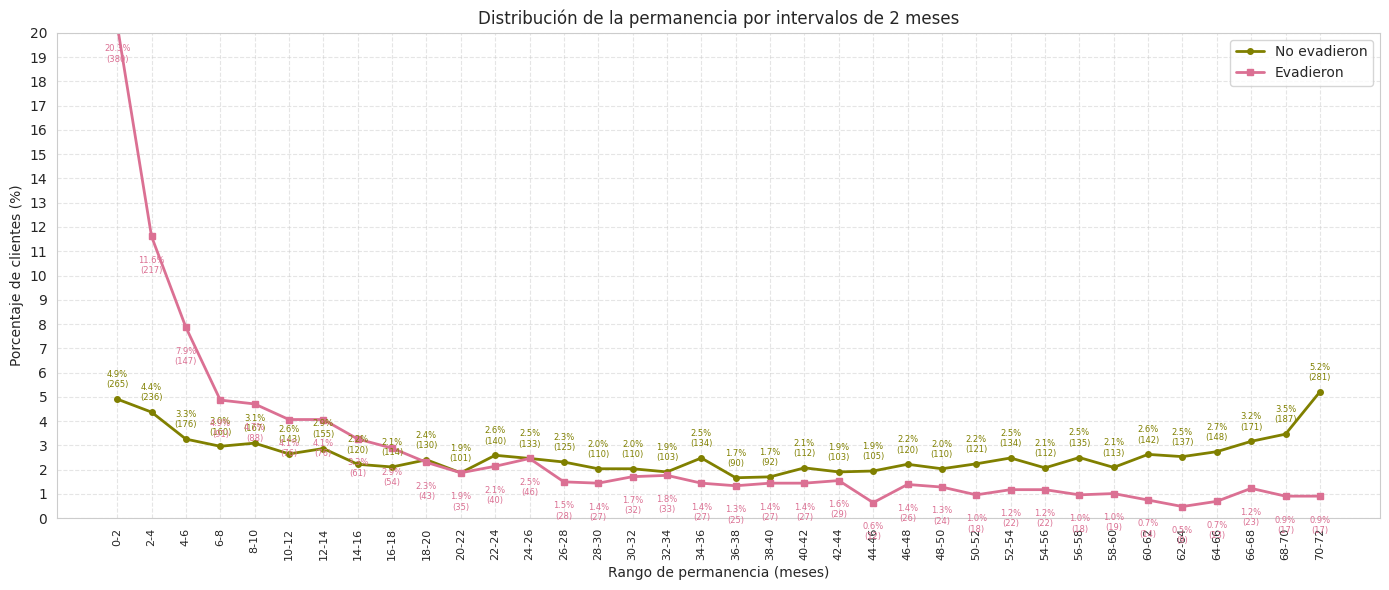

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Crear intervalos de 2 meses desde 0 hasta 72
bins = np.arange(0, 74, 2)
labels = [f'{i}-{i+2}' for i in range(0, 72, 2)]

df['rango_permanencia'] = pd.cut(df['Meses_Permanencia'], bins=bins, labels=labels, right=False, include_lowest=True)

no_evadidos = df[df['evasion'] == 0]
evadidos = df[df['evasion'] == 1]

freq_no = no_evadidos['rango_permanencia'].value_counts().sort_index()
freq_si = evadidos['rango_permanencia'].value_counts().sort_index()

pct_no = (freq_no / len(no_evadidos)) * 100
pct_si = (freq_si / len(evadidos)) * 100

# Rellenar con ceros
for rango in labels:
    if rango not in freq_no.index:
        freq_no[rango] = 0
        pct_no[rango] = 0
    if rango not in freq_si.index:
        freq_si[rango] = 0
        pct_si[rango] = 0

freq_no = freq_no.sort_index()
freq_si = freq_si.sort_index()
pct_no = pct_no.sort_index()
pct_si = pct_si.sort_index()

plt.figure(figsize=(14, 6))
x = np.arange(len(labels))

plt.plot(x, pct_no.values, marker='o', linestyle='-', linewidth=2, color='#808000', label='No evadieron', markersize=4)
plt.plot(x, pct_si.values, marker='s', linestyle='-', linewidth=2, color='#DB7093', label='Evadieron', markersize=4)

plt.xticks(x, labels, rotation=90, fontsize=8)
plt.xlabel('Rango de permanencia (meses)')
plt.ylabel('Porcentaje de clientes (%)')
plt.title('Distribución de la permanencia por intervalos de 2 meses')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Establecer límites del eje Y y ticks de 1 en 1
plt.ylim(0, 20)
plt.yticks(np.arange(0, 21, 1))

# Etiquetas en TODOS los puntos
for i in range(len(x)):
    # No evadidos (verde) - arriba del punto
    plt.text(x[i], pct_no.iloc[i] + 0.4, f'{pct_no.iloc[i]:.1f}%\n({int(freq_no.iloc[i])})',
             ha='center', va='bottom', fontsize=6, color='#808000')
    # Evadidos (rosado) - abajo del punto
    plt.text(x[i], pct_si.iloc[i] - 0.8, f'{pct_si.iloc[i]:.1f}%\n({int(freq_si.iloc[i])})',
             ha='center', va='top', fontsize=6, color='#DB7093')

plt.tight_layout()
plt.show()

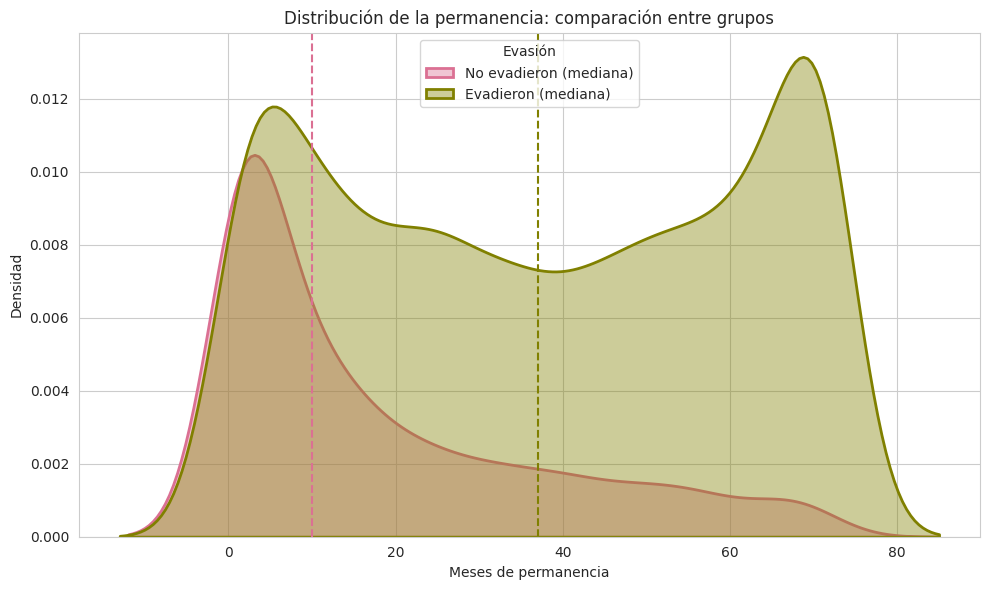

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# Colores personalizados
colores = {0: '#808000', 1: '#DB7093'}

# Gráfico de densidad (KDE) con fill
sns.kdeplot(data=df, x='Meses_Permanencia', hue='evasion',
            palette=colores, fill=True, alpha=0.4, linewidth=2)

# Añadir líneas verticales para las medianas
mediana_no = df[df['evasion'] == 0]['Meses_Permanencia'].median()
mediana_si = df[df['evasion'] == 1]['Meses_Permanencia'].median()

plt.axvline(mediana_no, color='#808000', linestyle='--', linewidth=1.5, label=f'Mediana no evadidos: {mediana_no:.0f} meses')
plt.axvline(mediana_si, color='#DB7093', linestyle='--', linewidth=1.5, label=f'Mediana evadidos: {mediana_si:.0f} meses')

# Personalizar
plt.xlabel('Meses de permanencia')
plt.ylabel('Densidad')
plt.title('Distribución de la permanencia: comparación entre grupos')
plt.legend(title='Evasión', labels=['No evadieron (mediana)', 'Evadieron (mediana)'])
plt.tight_layout()
plt.show()

Resulta que los clientes que se fueron (1.869 personas, o sea, 1 de cada 4) no duraron mucho en la empresa. La mitad de ellos duró menos de 10 meses. O sea, apenas empezaban y ya se iban. Hay un montón que ni siquiera llegó a los 2 meses (25% de ellos). Y el 75% de los que se fueron ya no estaban antes de los 2 años y medio.

En cambio, los que todavía están (5.398 clientes) son todo lo contrario: la mitad lleva más de 3 años (37 meses). Hay un montón que llevan muchísimo: 1 de cada 4 supera los 5 años (61 meses). O sea, si pasas los primeros meses, seguro te quedas un montón.


Puede ser que el peligro está al principio. Si logramos que un cliente pase su primer año, probablemente se quede mucho más. Hay que cuidar a los nuevos, ayudarlos, darles cariño, porque en esos primeros meses es cuando están más tentados a irse.




In [59]:
df['Cargo_Mensual'] = pd.to_numeric(df['Cargo_Mensual'], errors='coerce')
df['evasion'] = pd.to_numeric(df['evasion'], errors='coerce')

# Calcular correlación
correlacion = df[['Cargo_Mensual', 'evasion']].corr()

print("Matriz de correlación:")
print(correlacion)

# Extraer el valor específico
r = correlacion.loc['Cargo_Mensual', 'evasion']
print(f"\nCorrelación entre Cargo Mensual y Evasión: {r:.4f}")

Matriz de correlación:
               Cargo_Mensual   evasion
Cargo_Mensual       1.000000  0.189866
evasion             0.189866  1.000000

Correlación entre Cargo Mensual y Evasión: 0.1899


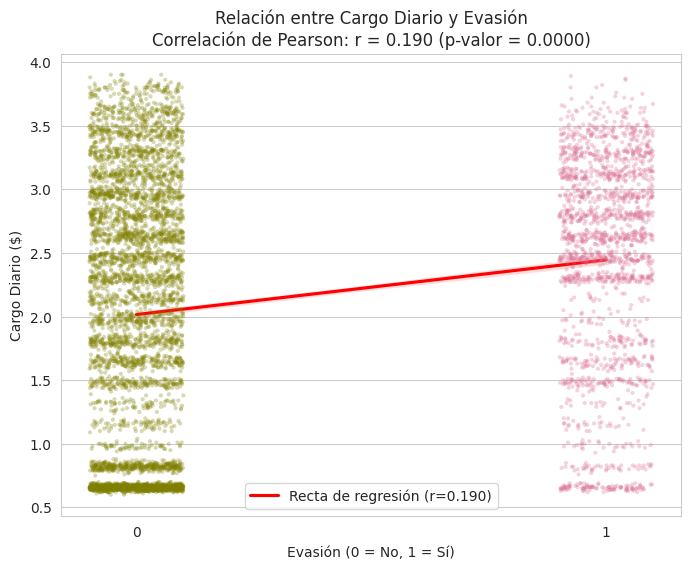

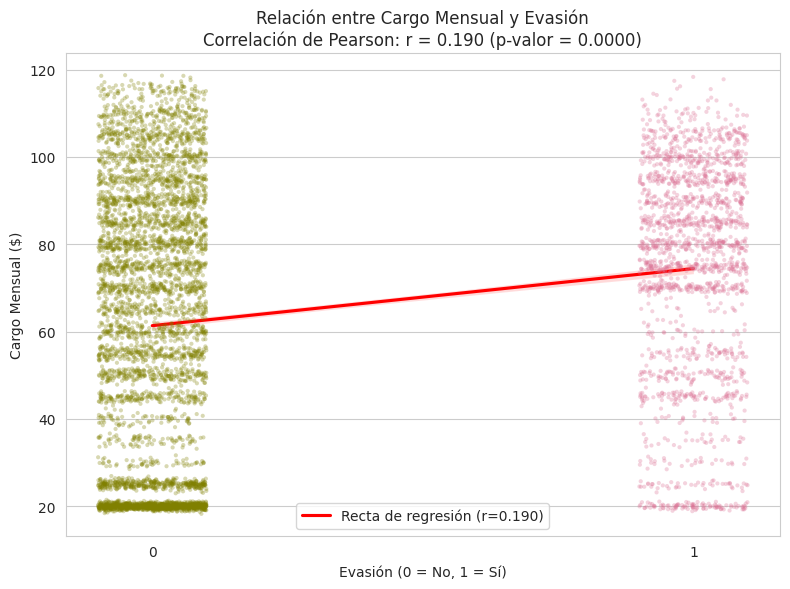

In [64]:
from scipy.stats import pearsonr
r, p = pearsonr(df['Cargo_Diario'], df['evasion'])

# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de dispersión con jitter (puntos por grupo)
sns.stripplot(data=df, x='evasion', y='Cargo_Diario', hue='evasion',
              jitter=True, alpha=0.3, palette=['#808000', '#DB7093'],
              size=3, legend=False, ax=ax)

# Recta de regresión (tendencia entre grupos)
sns.regplot(data=df, x='evasion', y='Cargo_Diario', scatter=False, ci=95,
            line_kws={'color': 'red'}, label=f'Recta de regresión (r={r:.3f})', ax=ax)

# Personalización
ax.set_xlabel('Evasión (0 = No, 1 = Sí)')
ax.set_ylabel('Cargo Diario ($)')
ax.set_title(f'Relación entre Cargo Diario y Evasión\nCorrelación de Pearson: r = {r:.3f} (p-valor = {p:.4f})')
ax.legend()





# Calcular correlación
r, p = pearsonr(df['Cargo_Mensual'], df['evasion'])

# Crear figura y eje
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de dispersión con jitter
sns.stripplot(data=df, x='evasion', y='Cargo_Mensual', hue='evasion',
              jitter=True, alpha=0.3, palette=['#808000', '#DB7093'],
              size=3, legend=False, ax=ax)

# Añadir recta de regresión (con label para la leyenda)
sns.regplot(data=df, x='evasion', y='Cargo_Mensual', scatter=False, ci=95,
            line_kws={'color': 'red'}, label=f'Recta de regresión (r={r:.3f})', ax=ax)

# Personalizar
ax.set_xlabel('Evasión (0 = No, 1 = Sí)')
ax.set_ylabel('Cargo Mensual ($)')
ax.set_title(f'Relación entre Cargo Mensual y Evasión\nCorrelación de Pearson: r = {r:.3f} (p-valor = {p:.4f})')

# Mostrar leyenda (solo incluirá la línea de regresión)
ax.legend()

plt.tight_layout()
plt.show()

Hay una correlación positiva de 0.19 entre lo que paga un cliente y si se va. Los que se fueron pagaban en promedio 74 mensuales. Los que se quedaron pagan 61 mensuales. Diferencia: 13.